# 02 — Baseline Forecasting (LightGBM + MLP)

Reference taken from https://github.com/unizg-fer-lares/dataset-pv/blob/main/python/pv_power_forecasting/forecasting.py, converted .py into pynb

> **Note on MLP:** Used `sklearn.neural_network.MLPRegressor` (same 64→32→1 architecture as the forecasting.py Keras model) to avoid TensorFlow kernel crashes on Apple Silicon Macs. The model behaviour is equivalent.

**Run `01_data_processing.ipynb` first** to produce `data/dataset.csv`.

**What it does:**
1. Loads `dataset.csv`
2. Resamples to 15-minute intervals (power = sum in kWh, weather = mean)
3. Drops nighttime rows (power ≤ 0)
4. Adds calendar features (sin/cos encoding of hour and day-of-year)
5. Splits by date: train = before 2020-01-01, test = 2020-01-01 to 2020-08-01
6. Trains LightGBM (baseline + grid-search tuned) and a small MLP
7. Reports MAE, RMSE, R², nRMSE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

import lightgbm as lgb

SEED = 321
np.random.seed(SEED)

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load dataset.csv

In [2]:
df = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)

print(f'Shape : {df.shape}')
print(f'Range : {df.index.min()}  →  {df.index.max()}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape : (2204759, 7)
Range : 2018-04-17 05:24:00  →  2023-03-04 22:54:00
Columns: ['power', 'sun_zenith', 'sun_azimuth', 'temperature', 'global_irradiance', 'direct_irradiance', 'diffuse_irradiance']


,power,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance
timestamp,,,,,,,
2018-04-17 05:24:00,0.000050,77.63,-92.47,14.1,7,0,7
2018-04-17 05:25:00,0.000050,77.46,-92.29,14.1,8,0,8
2018-04-17 05:26:00,0.000050,77.28,-92.12,14.1,8,0,8
2018-04-17 05:27:00,0.000050,77.11,-91.94,14.1,9,0,9
2018-04-17 05:28:00,0.000067,76.93,-91.76,14.1,10,0,10


In [3]:
local_tz = 'Europe/Zagreb'
df.index = df.index.tz_localize('UTC').tz_convert(local_tz).tz_localize(None)

print(f'Timezone converted to {local_tz}')
print(f'New range: {df.index.min()}  →  {df.index.max()}')

Timezone converted to Europe/Zagreb
New range: 2018-04-17 07:24:00  →  2023-03-04 23:54:00


## 2. Resample to 15 minutes + drop nighttime

In [4]:
agg = {
    'power'             : 'sum',
    'sun_zenith'        : 'mean',
    'sun_azimuth'       : 'mean',
    'temperature'       : 'mean',
    'global_irradiance' : 'mean',
    'direct_irradiance' : 'mean',
    'diffuse_irradiance': 'mean',
}

df = df.resample('15min', closed='left', label='left').agg(agg)
df = df[df['power'] > 0].dropna()

print(f'Shape  : {df.shape}')
print(f'Range  : {df.index.min()}  →  {df.index.max()}')
df.head()

Shape  : (38933, 7)
Range  : 2018-04-17 07:15:00  →  2020-12-19 09:45:00


,power,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance
timestamp,,,,,,,
2018-04-17 07:15:00,0.000283,77.195000,-92.026667,14.100000,9.000000,0.0,9.000000
2018-04-17 07:30:00,0.003250,75.363333,-90.153333,14.200000,20.866667,0.0,20.800000
2018-04-17 07:45:00,0.018767,72.747333,-87.450000,14.446667,49.800000,0.0,49.800000
2018-04-17 08:00:00,0.024600,70.137333,-84.700667,14.673333,63.266667,0.0,63.733333
2018-04-17 08:15:00,0.027450,67.539333,-81.896667,14.820000,66.533333,0.0,66.800000


## 3. Feature Engineering

In [5]:
df['hour'] = df.index.hour + df.index.minute / 60.0
df['doy']  = df.index.dayofyear

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['doy_sin']  = np.sin(2 * np.pi * df['doy']  / 366.0)
df['doy_cos']  = np.cos(2 * np.pi * df['doy']  / 366.0)

df = df.drop(columns=['hour', 'doy'])

print('Features:', df.columns.tolist())
print(f'Total rows: {len(df)}')

Features: ['power', 'sun_zenith', 'sun_azimuth', 'temperature', 'global_irradiance', 'direct_irradiance', 'diffuse_irradiance', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
Total rows: 38933


## 4. Train / Test Split by Date

- **Train**: before 2020-01-01
- **Test**: 2020-01-01 → 2020-08-01

In [6]:
test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2020-08-01')

target   = 'power'
features = [c for c in df.columns if c != target]

df_train = df[df.index < test_start]
df_test  = df[(df.index >= test_start) & (df.index <= test_end)]

X_train, y_train = df_train[features].values, df_train[target].values
X_test,  y_test  = df_test[features].values,  df_test[target].values

print(f'Train: {X_train.shape}  ({df_train.index.min().date()} → {df_train.index.max().date()})')
print(f'Test : {X_test.shape}   ({df_test.index.min().date()}  → {df_test.index.max().date()})')

Train: (23638, 10)  (2018-04-17 → 2019-12-31)
Test : (10466, 10)   (2020-01-01  → 2020-07-31)


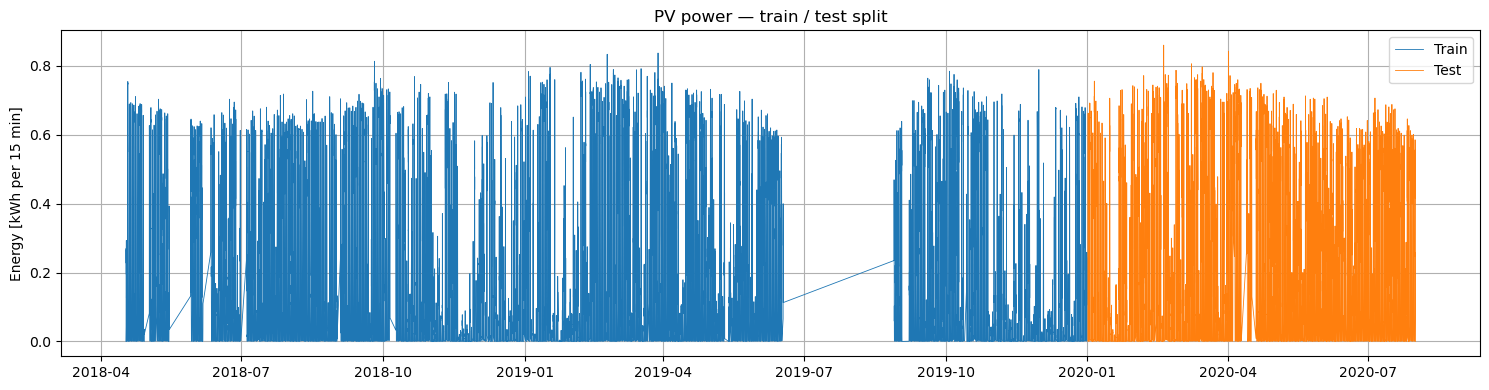

Saved → ../figure/02_train_test_split.png


In [7]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_train.index, y_train, label='Train', linewidth=0.6)
ax.plot(df_test.index,  y_test,  label='Test',  linewidth=0.6)
ax.set_title('PV power — train / test split')
ax.set_ylabel('Energy [kWh per 15 min]')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('../figure/02_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/02_train_test_split.png')

## 5. Helper: Metrics + Plot Function

In [8]:
def evaluate(name, y_true, y_pred):
    """Compute MAE/RMSE/R²/nRMSE, print, plot, save figure."""
    y_pred = np.clip(y_pred, 0, None)
    y_true = np.asarray(y_true)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    nrmse = rmse / y_true.max()

    print(f'\n[{name}]')
    print(f'  MAE   = {mae:.4f} kWh')
    print(f'  RMSE  = {rmse:.4f} kWh')
    print(f'  R²    = {r2:.4f}')
    print(f'  nRMSE = {nrmse:.4f}')

    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    lim = max(float(y_true.max()), float(y_pred.max())) * 1.05
    axes[0].scatter(y_true, y_pred, s=4, alpha=0.3)
    axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
    axes[0].set_title(f'{name}: Predicted vs Actual')
    axes[0].grid(True)

    week = 7 * 24 * 4
    axes[1].plot(y_true[-week:], label='Actual')
    axes[1].plot(y_pred[-week:], label='Predicted')
    axes[1].set_title(f'{name}: Last week of test period')
    axes[1].set_ylabel('kWh'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    fname = f'../figure/02_{slug}_eval.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'nRMSE': nrmse}

results = []

## 6. Model 1 — LightGBM (baseline params)

Training LightGBM...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train time : 0.78s
Infer time : 0.0142s

[LightGBM]
  MAE   = 0.0212 kWh
  RMSE  = 0.0348 kWh
  R²    = 0.9766
  nRMSE = 0.0405


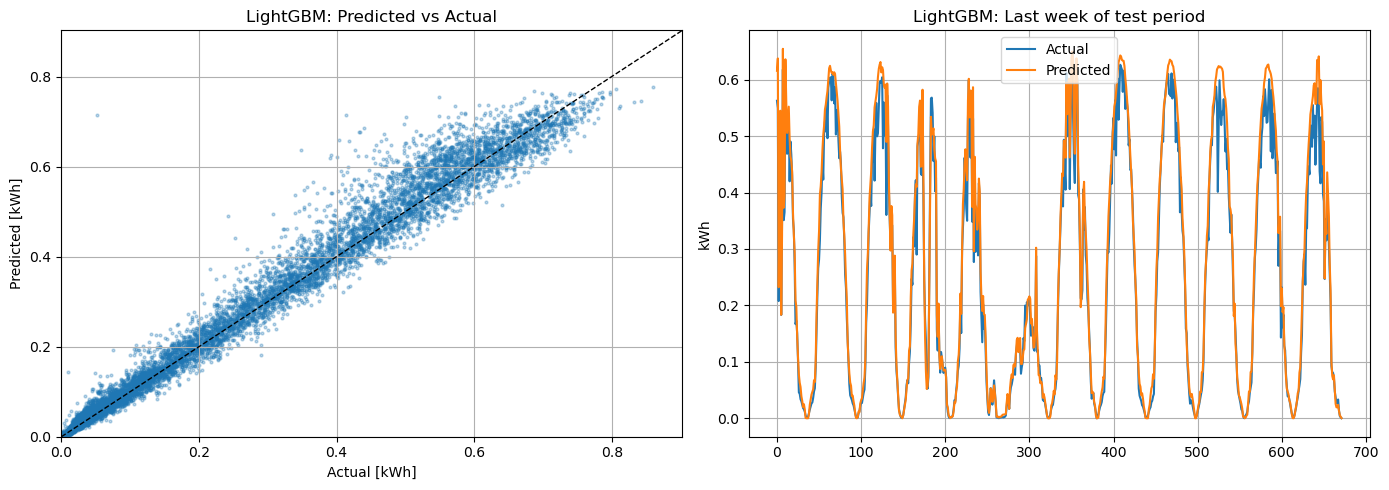

Saved → ../figure/02_lightgbm_eval.png


In [9]:
print('Training LightGBM...')

lgbm_params = {
    'boosting_type'    : 'gbdt',
    'objective'        : 'regression',
    'metric'           : 'mae',
    'learning_rate'    : 0.1,
    'n_estimators'     : 200,
    'num_leaves'       : 31,
    'min_child_samples': 25,
    'subsample'        : 0.9,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.4,
    'reg_lambda'       : 0.01,
    'random_state'     : SEED,
    'verbose'          : -1,
}

t0 = time.time()
lgbm = lgb.LGBMRegressor(**lgbm_params)
lgbm.fit(X_train, y_train)
train_time_lgbm = time.time() - t0

t0 = time.time()
y_pred_lgbm = lgbm.predict(X_test)
infer_time_lgbm = time.time() - t0

print(f'Train time : {train_time_lgbm:.2f}s')
print(f'Infer time : {infer_time_lgbm:.4f}s')

r = evaluate('LightGBM', y_test, y_pred_lgbm)
r['Train Time'] = train_time_lgbm
r['Inference Time'] = infer_time_lgbm
results.append(r)

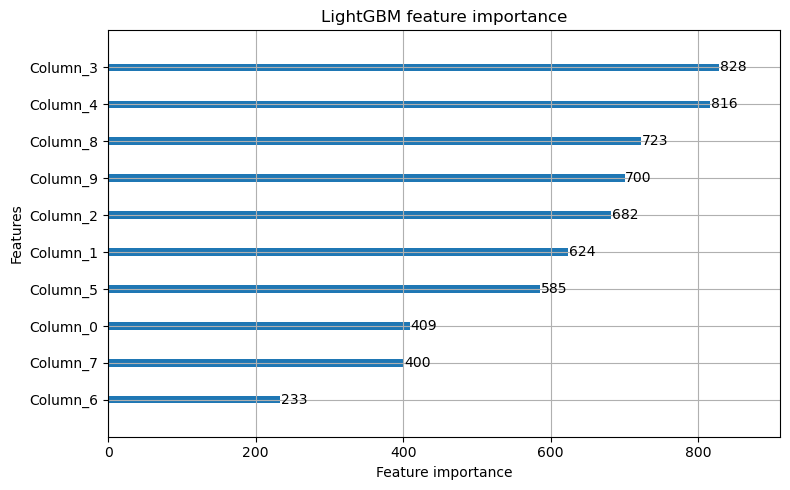

Saved → ../figure/02_lightgbm_feature_importance.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
lgb.plot_importance(lgbm, ax=ax, max_num_features=15)
ax.set_title('LightGBM feature importance')
plt.tight_layout()
plt.savefig('../figure/02_lightgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/02_lightgbm_feature_importance.png')

## 7. Model 2 — LightGBM with Grid Search (tuned)

Running LightGBM grid search (this may take a few minutes)...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

Best params : {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 63}
Train time  : 48.51s

[LightGBM (tuned)]
  MAE   = 0.0209 kWh
  RMSE  = 0.0345 kWh
  R²    = 0.9769
  nRMSE = 0.0402


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


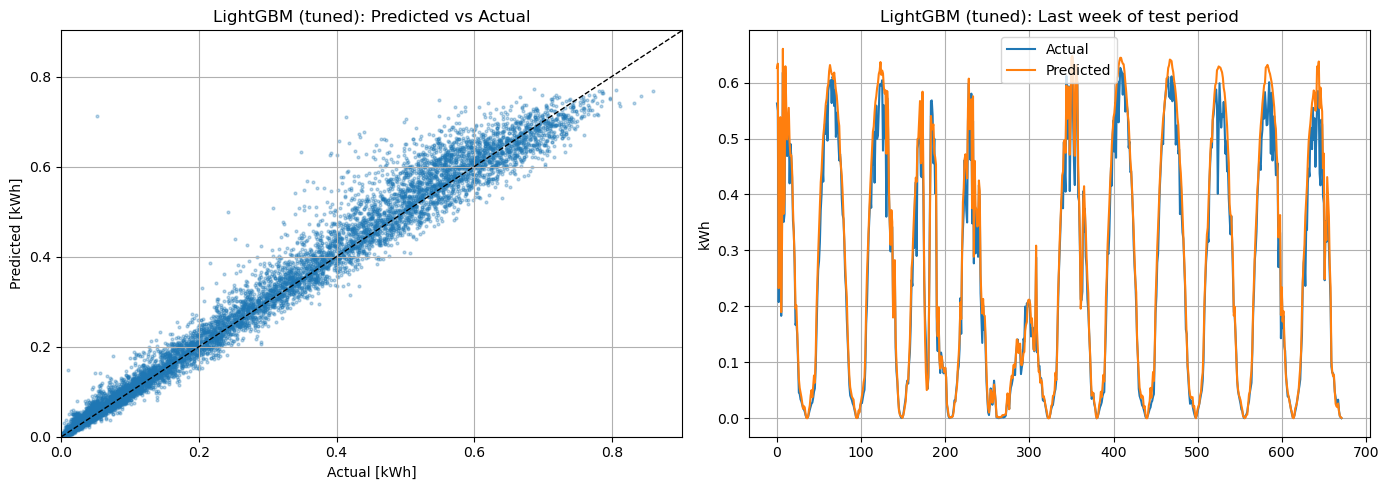

Saved → ../figure/02_lightgbm_tuned_eval.png


In [11]:
print('Running LightGBM grid search (this may take a few minutes)...')

param_grid = {
    'learning_rate': [0.05, 0.1],
    'n_estimators' : [100, 200, 400],
    'num_leaves'   : [15, 31, 63],
}

gbm  = lgb.LGBMRegressor(**{**lgbm_params, 'n_estimators': 100})
grid = GridSearchCV(gbm, param_grid, cv=3,
                    scoring='neg_mean_absolute_error', n_jobs=-1)

t0 = time.time()
grid.fit(X_train, y_train)
train_time_lgbm_tuned = time.time() - t0

print(f'Best params : {grid.best_params_}')
print(f'Train time  : {train_time_lgbm_tuned:.2f}s')

t0 = time.time()
y_pred_lgbm_tuned = grid.best_estimator_.predict(X_test)
infer_time_lgbm_tuned = time.time() - t0

r = evaluate('LightGBM (tuned)', y_test, y_pred_lgbm_tuned)
r['Train Time'] = train_time_lgbm_tuned
r['Inference Time'] = infer_time_lgbm_tuned
results.append(r)

## 8. Model 3 — Small MLP (scikit-learn)

Architecture: Input → 64 → 32 → 1  
Same structure as the professor's Keras model, using `sklearn.neural_network.MLPRegressor` to avoid TensorFlow dependency.

In [12]:
# Scale to N(0,1) — NNs require normalised inputs
X_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))

X_train_s = X_scaler.transform(X_train)
X_test_s  = X_scaler.transform(X_test)
y_train_s = y_scaler.transform(y_train.reshape(-1, 1)).ravel()

print('Data scaled ✓')

Data scaled ✓


Training MLP...
Stopped after 75 iterations
Train time : 3.51s


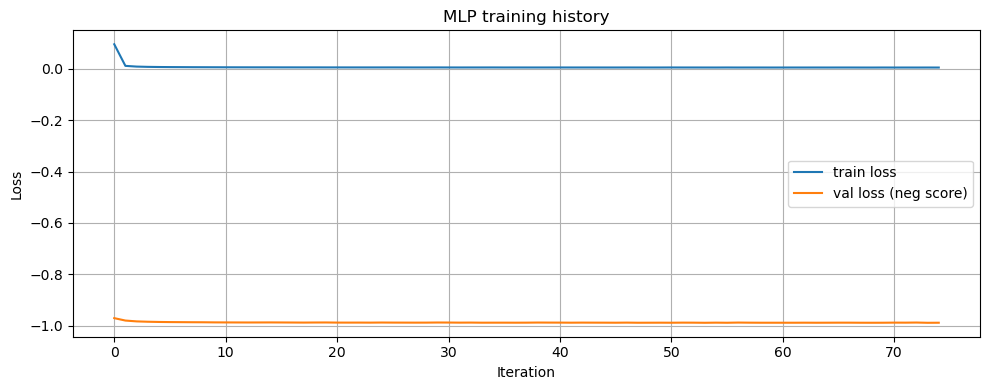

Saved → ../figure/02_mlp_training_history.png


In [13]:
print('Training MLP...')

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),   # same as professor's 64→32→1
    activation='relu',
    solver='adam',
    alpha=1e-3,                    # L2 regularisation (matches keras l2(1e-3))
    batch_size=256,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=20,           # patience=20 like professor's EarlyStopping
    random_state=SEED,
    verbose=False,
)

t0 = time.time()
mlp.fit(X_train_s, y_train_s)
train_time_mlp = time.time() - t0

print(f'Stopped after {mlp.n_iter_} iterations')
print(f'Train time : {train_time_mlp:.2f}s')

# Plot training loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp.loss_curve_, label='train loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax.plot([-s for s in mlp.validation_scores_], label='val loss (neg score)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
ax.set_title('MLP training history')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('../figure/02_mlp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/02_mlp_training_history.png')


[MLP]
  MAE   = 0.0209 kWh
  RMSE  = 0.0345 kWh
  R²    = 0.9770
  nRMSE = 0.0401


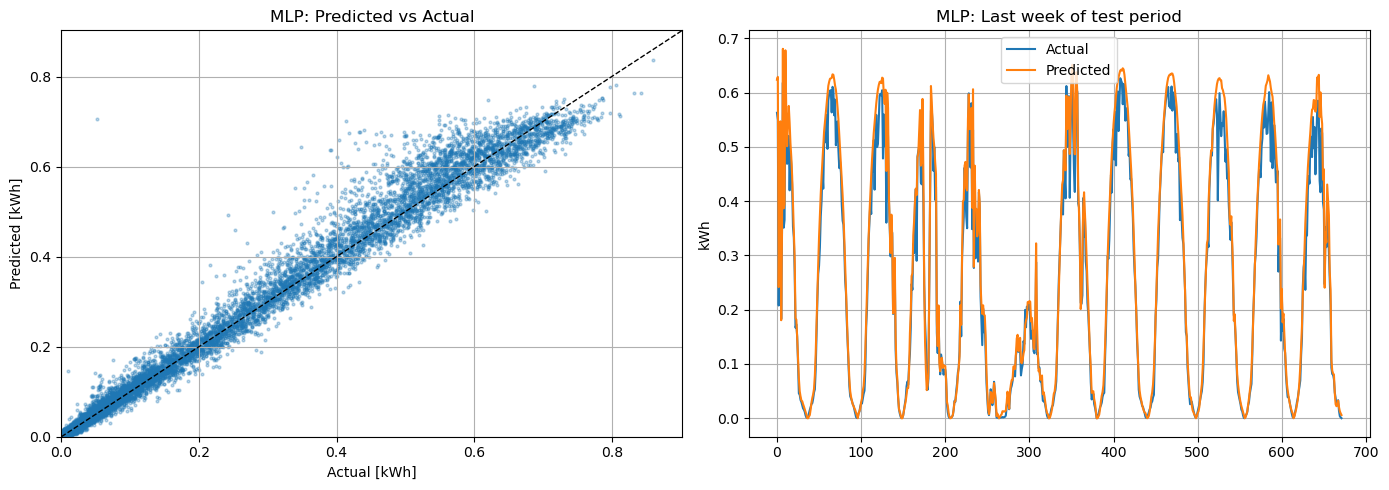

Saved → ../figure/02_mlp_eval.png


In [14]:
t0 = time.time()
y_pred_nn_s = mlp.predict(X_test_s)
infer_time_mlp = time.time() - t0

# Inverse-transform back to kWh
y_pred_nn = y_scaler.inverse_transform(y_pred_nn_s.reshape(-1, 1)).ravel()

r = evaluate('MLP', y_test, y_pred_nn)
r['Train Time'] = train_time_mlp
r['Inference Time'] = infer_time_mlp
results.append(r)

## 9. Summary Table


  BASELINE RESULTS
           Model      MAE     RMSE       R2    nRMSE  Inference Time
        LightGBM 0.021175 0.034823 0.976566 0.040512        0.014204
LightGBM (tuned) 0.020895 0.034539 0.976946 0.040182        0.033761
             MLP 0.020945 0.034464 0.977046 0.040095        0.009781


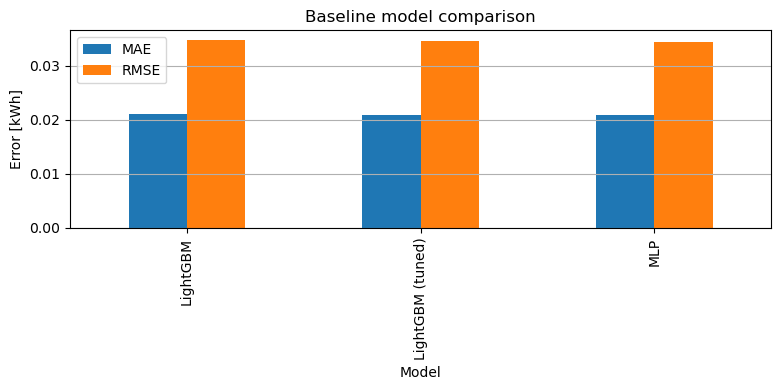

Saved → ../figure/02_baseline_comparison.png


In [15]:
summary = pd.DataFrame(results)

print('\n' + '='*65)
print('  BASELINE RESULTS')
print('='*65)
print(summary[['Model','MAE','RMSE','R2','nRMSE','Inference Time']].to_string(index=False))
print('='*65)

fig, ax = plt.subplots(figsize=(8, 4))
summary.set_index('Model')[['MAE','RMSE']].plot(kind='bar', ax=ax)
ax.set_title('Baseline model comparison')
ax.set_ylabel('Error [kWh]')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('../figure/02_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/02_baseline_comparison.png')

## 10. Save Results

In [16]:
actual_arr = np.asarray(y_test)

pd.DataFrame({
    'actual'   : actual_arr,
    'lightgbm' : np.clip(y_pred_lgbm, 0, None),
}).to_pickle('../results/lightgbm_predictions.pkl')

pd.DataFrame({
    'actual'         : actual_arr,
    'lightgbm_tuned' : np.clip(y_pred_lgbm_tuned, 0, None),
}).to_pickle('../results/lightgbm_tuned_predictions.pkl')

pd.DataFrame({
    'actual' : actual_arr,
    'mlp'    : np.clip(y_pred_nn, 0, None),
}).to_pickle('../results/mlp_predictions.pkl')

pd.Series(df_test.index, name='timestamp').to_csv('../results/test_timestamps.csv', index=False)

print('Saved → ../results/lightgbm_predictions.pkl')
print('Saved → ../results/lightgbm_tuned_predictions.pkl')
print('Saved → ../results/mlp_predictions.pkl')
print('Saved → ../results/test_timestamps.csv')

Saved → ../results/lightgbm_predictions.pkl
Saved → ../results/lightgbm_tuned_predictions.pkl
Saved → ../results/mlp_predictions.pkl
Saved → ../results/test_timestamps.csv


In [17]:
comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']

new_rows = pd.DataFrame([
    {
        'Model'          : r['Model'],
        'MAE'            : r['MAE'],
        'RMSE'           : r['RMSE'],
        'nRMSE'          : r['nRMSE'],
        'Train Time'     : r['Train Time'],
        'Inference Time' : r['Inference Time'],
    }
    for r in results
])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows

combined[comp_cols].to_csv(comp_path, index=False)

print(f'Saved → {comp_path}')
print()
print(combined[comp_cols].to_string(index=False))

Saved → ../results/comparison.csv

           Model      MAE     RMSE    nRMSE  Train Time  Inference Time
        LightGBM 0.021175 0.034823 0.040512    0.776353        0.014204
LightGBM (tuned) 0.020895 0.034539 0.040182   48.507317        0.033761
             MLP 0.020945 0.034464 0.040095    3.505997        0.009781
